In [1]:
# ===============================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Pruebas estadísticas para validar PCA
from factor_analyzer.factor_analyzer import calculate_kmo
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity

In [2]:
# ===============================
# 2. CARGA DEL DATASET
# ===============================

df = pd.read_csv("movies_2026.csv", encoding="latin1")

df.head()

,id,budget,genres,homePage,productionCompany,productionCompanyCountry,productionCountry,revenue,runtime,video,...,releaseDate,voteAvg,voteCount,genresAmount,productionCoAmount,productionCountriesAmount,actorsAmount,castWomenAmount,castMenAmount,releaseYear
0,1627085,0.0,Drama|Crime,NaN,NaN,NaN,NaN,0.0,95,False,...,2026-02-01,0.0,0,2,0,0,8,2.0,5.0,2026.0
1,1626914,0.0,Animation,NaN,NaN,NaN,NaN,0.0,3,False,...,2026-02-01,0.0,0,1,0,0,4,0.0,0.0,2026.0
2,1626898,0.0,Animation,NaN,NaN,NaN,NaN,0.0,2,False,...,2026-02-01,0.0,0,1,0,0,3,0.0,0.0,2026.0
3,1626808,0.0,Thriller|Mystery|Documentary,NaN,NaN,NaN,NaN,0.0,5,False,...,2026-02-01,0.0,0,3,0,0,7,0.0,0.0,2026.0
4,1626678,0.0,Animation,NaN,NaN,NaN,NaN,0.0,12,False,...,2026-02-01,0.0,0,1,0,0,3,0.0,0.0,2026.0


In [3]:
# ===============================
# 3. SELECCIÓN DE VARIABLES NUMÉRICAS
# ===============================

df_num = df.select_dtypes(include=['int64', 'float64'])

# Eliminar id porque no aporta información
if 'id' in df_num.columns:
    df_num = df_num.drop(columns=['id'])

print("Variables numéricas utilizadas:")
df_num.columns

Variables numéricas utilizadas:


Index(['budget', 'revenue', 'runtime', 'popularity', 'voteAvg', 'voteCount',
       'genresAmount', 'productionCoAmount', 'productionCountriesAmount',
       'actorsAmount', 'castWomenAmount', 'castMenAmount', 'releaseYear'],
      dtype='str')

In [4]:
# ===============================
# 4. MANEJO DE VALORES NULOS
# ===============================

print("Valores nulos por variable:")
print(df_num.isnull().sum())

# Eliminamos filas con nulos
df_num = df_num.dropna()

print("Dimensiones después de eliminar nulos:", df_num.shape)

Valores nulos por variable:
budget                         0
revenue                        0
runtime                        0
popularity                     0
voteAvg                        0
voteCount                      0
genresAmount                   0
productionCoAmount             0
productionCountriesAmount      0
actorsAmount                   0
castWomenAmount               37
castMenAmount                162
releaseYear                    2
dtype: int64
Dimensiones después de eliminar nulos: (19719, 13)


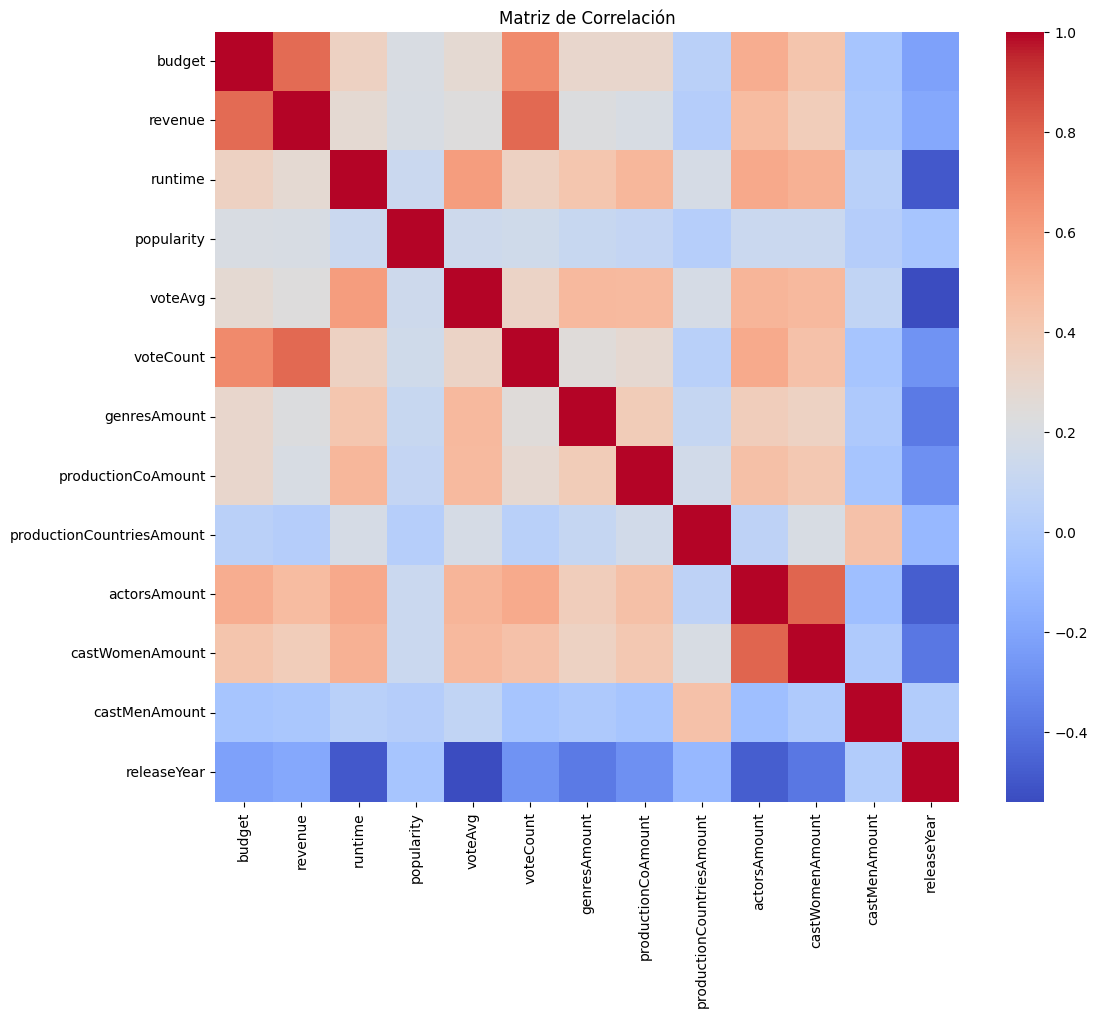

In [5]:
# ===============================
# 5. MATRIZ DE CORRELACIÓN
# ===============================

plt.figure(figsize=(12,10))
sns.heatmap(df_num.corr(), cmap='coolwarm')
plt.title("Matriz de Correlación")
plt.show()